# MODIS NDVI Exploratory Analysis
## Fetching & visualizing vegetation data from NASA's GIBS API

This notebook connects to NASA's Global Imagery Browse Services (GIBS) to explore MODIS NDVI (Normalized Difference Vegetation Index) data across time and space. We'll:

1. Connect to the GIBS WMS service and explore available MODIS layers
2. Fetch NDVI imagery for different time periods
3. Extract numerical data from the imagery
4. Create exploratory visualizations (time series, comparisons, heatmaps)

**Dataset**: MODIS Terra / Aqua — 8-day NDVI composites  
**API**: [NASA GIBS WMS](https://gibs.earthdata.nasa.gov/wms/epsg4326/best/wms.cgi?)

In [1]:
# 1. Install & Import Libraries

import sys
!pip install owslib pillow matplotlib numpy pandas requests -q

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from owslib.wms import WebMapService
from io import BytesIO
from PIL import Image
import requests
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")
print(f"Python version: {sys.version}")

All libraries loaded successfully!
Python version: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


In [2]:
# 2. Connect to NASA GIBS WMS Service

# Geographic projection WMS endpoint
WMS_URL = 'https://gibs.earthdata.nasa.gov/wms/epsg4326/best/wms.cgi?'

# Connect with both supported versions
wms_111 = WebMapService(WMS_URL, version='1.1.1')
wms_130 = WebMapService(WMS_URL, version='1.3.0')

print(f"Identification: {wms_130.identification.title}")
print(f"Version: {wms_130.identification.version}")
print(f"Provider: {wms_130.provider.name}")
print("Connection successful!")

Identification: NASA Global Imagery Browse Services for EOSDIS WMS (EPSG:4326 / best)
Version: 1.3.0
Provider: EOSDIS NASA GIBS
Connection successful!


In [3]:
# 3. Discover MODIS Vegetation Layers

# Get all available layer names
contents = list(wms_130.contents)

# Search for MODIS-related layers with vegetation/NDVI keywords
keywords = ['NDVI', 'Vegetation', 'Green', 'MODIS']
modis_veg_layers = []

for name in contents:
    if any(kw.lower() in name.lower() for kw in keywords):
        modis_veg_layers.append(name)

print(f"Found {len(modis_veg_layers)} vegetation/NDVI-related MODIS layers:\n")
for layer in sorted(modis_veg_layers):
    print(f"  • {layer}")

print("\n---\n")

# Also show some other interesting MODIS layers
print("Other interesting MODIS layers for context:")
other_modis = [n for n in contents if 'MODIS' in n and 'NDVI' not in n and 'Vegetation' not in n][:8]
for layer in other_modis:
    print(f"  • {layer}")

Found 259 vegetation/NDVI-related MODIS layers:

  • Landsat_WELD_NDVI_Global_Annual
  • Landsat_WELD_NDVI_Global_Monthly
  • MISR_Aerosol_Optical_Depth_Avg_Green_Monthly
  • MISR_Land_NDVI_Average_Monthly
  • MODIS_Aqua_AOD_Deep_Blue_Combined
  • MODIS_Aqua_AOD_Deep_Blue_Land
  • MODIS_Aqua_Aerosol
  • MODIS_Aqua_Aerosol_Optical_Depth_3km
  • MODIS_Aqua_Angstrom_Exponent_Land
  • MODIS_Aqua_Angstrom_Exponent_Ocean
  • MODIS_Aqua_Brightness_Temp_Band31_Day
  • MODIS_Aqua_Brightness_Temp_Band31_Night
  • MODIS_Aqua_Cloud_Effective_Radius
  • MODIS_Aqua_Cloud_Effective_Radius_16
  • MODIS_Aqua_Cloud_Effective_Radius_1621
  • MODIS_Aqua_Cloud_Effective_Radius_16_PCL
  • MODIS_Aqua_Cloud_Effective_Radius_37
  • MODIS_Aqua_Cloud_Effective_Radius_37_PCL
  • MODIS_Aqua_Cloud_Effective_Radius_PCL
  • MODIS_Aqua_Cloud_Effective_Radius_PCL_1621
  • MODIS_Aqua_Cloud_Fraction_Day
  • MODIS_Aqua_Cloud_Fraction_Night
  • MODIS_Aqua_Cloud_Multi_Layer_Flag
  • MODIS_Aqua_Cloud_Optical_Thickness
  • MO

## Fetch NDVI Data from GIBS

We'll use the `MODIS_Terra_L3_NDVI_16Day` layer, which provides 16-day composite NDVI at 1km resolution (available from 2000–present). NDVI values range from -1 to 1, where:
- **< 0**: Water, snow, clouds
- **0 – 0.2**: Barren rock, sand, urban
- **0.2 – 0.5**: Sparse vegetation (shrubs, grasslands)
- **0.5 – 0.8**: Moderate to dense vegetation
- **> 0.8**: Very dense tropical forests

The GIBS WMS returns rendered images (PNG/JPEG). We'll download them and extract numerical NDVI values from the pixel colors using the layer's color map.

In [12]:
# 4. Helper: Fetch NDVI Image & Extract Numerical Data

NDVI_LAYER = 'MODIS_Terra_L3_NDVI_16Day'

# ── Build proper NDVI colormap from the actual GIBS legend ──
# The legend gradient goes from NDVI=0 (left, brown/tan) to NDVI=1 (right, dark green)
# We sampled it from the legend PNG at https://gibs.earthdata.nasa.gov/legends/MODIS_L3_NDVI_H.png
# The color bar spans approximately x=40 to x=380 in the 420-wide legend.

# Pre-computed color samples along the legend gradient at regular intervals
# Format: (ndvi, R, G, B)
_NDVI_COLORMAP = [
    (0.00, 239, 231, 232),
    (0.05, 233, 224, 219),
    (0.10, 227, 216, 206),
    (0.15, 220, 208, 192),
    (0.20, 212, 197, 177),
    (0.25, 201, 182, 158),
    (0.30, 186, 162, 137),
    (0.35, 176, 142, 116),
    (0.40, 165, 118,  89),
    (0.42, 160, 100,  76),
    (0.44, 158, 108,  65),
    (0.46, 160, 140,  50),
    (0.48, 162, 175,  46),
    (0.50, 164, 198,  61),
    (0.52, 155, 192,  51),
    (0.55, 143, 186,  38),
    (0.58, 129, 179,  24),
    (0.60, 118, 172,  12),
    (0.63, 108, 166,   2),
    (0.66,  95, 160,   0),
    (0.69,  80, 151,   0),
    (0.72,  68, 143,   0),
    (0.75,  56, 135,   0),
    (0.78,  45, 128,   1),
    (0.81,  34, 120,   1),
    (0.84,  24, 112,   1),
    (0.87,  16, 104,   1),
    (0.90,   8,  96,   1),
    (0.93,   3,  86,   1),
    (0.96,   0,  70,   1),
    (1.00,   0,  36,   1),
]

# Pre-compute arrays for fast nearest-color matching
_cmap_rgb = np.array([[r, g, b] for _, r, g, b in _NDVI_COLORMAP], dtype=np.float32)
_cmap_ndvi = np.array([ndvi for ndvi, _, _, _ in _NDVI_COLORMAP], dtype=np.float32)


def rgb_to_ndvi(r, g, b):
    """Convert GIBS NDVI layer RGB pixel to NDVI via nearest-color lookup.
    
    Uses Euclidean distance in RGB space to find the closest color in the
    GIBS NDVI colormap, returning the corresponding NDVI value.
    """
    # Black (0,0,0) = transparent/no-data (typically ocean) — return NaN
    if r == 0 and g == 0 and b == 0:
        return np.nan
    
    # Very bright pixels (white) = snow/cloud — return negative NDVI
    if r > 220 and g > 220 and b > 220:
        return -0.1
    
    # Find nearest color in the colormap
    pixel = np.array([r, g, b], dtype=np.float32)
    dists = np.sqrt(np.sum((_cmap_rgb - pixel) ** 2, axis=1))
    return float(_cmap_ndvi[np.argmin(dists)])


def fetch_ndvi_image(date, bbox=(-180, -90, 180, 90), size=(720, 360)):
    """Download an NDVI image from GIBS WMS for a given date."""
    try:
        img = wms_130.getmap(
            layers=[NDVI_LAYER],
            srs='epsg:4326',
            bbox=bbox,
            size=size,
            time=date,
            format='image/png',
            transparent=True
        )
        pil_img = Image.open(BytesIO(img.read())).convert('RGB')
        return np.array(pil_img)
    except Exception as e:
        print(f"  ⚠ Failed to fetch {date}: {e}")
        return None


def image_to_ndvi_array(img_array):
    """Convert an RGB NDVI image array to a 2D array of NDVI values (vectorized)."""
    h, w, _ = img_array.shape
    pixels = img_array.reshape(-1, 3).astype(np.float32)
    
    # Mask for black (transparent) pixels
    is_black = (pixels[:, 0] == 0) & (pixels[:, 1] == 0) & (pixels[:, 2] == 0)
    
    # Mask for white/bright pixels (snow/cloud)
    is_white = (pixels[:, 0] > 220) & (pixels[:, 1] > 220) & (pixels[:, 2] > 220)
    
    # For each pixel, find nearest color in colormap
    ndvi_flat = np.full(pixels.shape[0], np.nan)
    
    # Process non-black, non-white pixels
    mask = ~is_black & ~is_white
    if np.any(mask):
        rgb_vals = pixels[mask]
        # Compute distances to all colormap entries
        dists = np.sqrt(np.sum((rgb_vals[:, np.newaxis, :] - _cmap_rgb[np.newaxis, :, :]) ** 2, axis=2))
        best_idx = np.argmin(dists, axis=1)
        ndvi_flat[mask] = _cmap_ndvi[best_idx]
    
    # White pixels get negative NDVI
    ndvi_flat[is_white] = -0.1
    
    return ndvi_flat.reshape(h, w)


def compute_zonal_average(ndvi_array, lat_bands=18):
    """Compute average NDVI for each latitude band (rows ~ latitude)."""
    h = ndvi_array.shape[0]
    band_size = h // lat_bands
    means = []
    for i in range(lat_bands):
        y_start = i * band_size
        y_end = (i + 1) * band_size if i < lat_bands - 1 else h
        band_data = ndvi_array[y_start:y_end, :]
        means.append(np.nanmean(band_data))
    
    # Latitude values (center of each band) from -90 to 90
    # Row 0 = top of image (90°N), row h-1 = bottom (-90°S)
    lats = np.linspace(90 - 90/lat_bands, -90 + 90/lat_bands, lat_bands)
    return lats, np.array(means)


def lat_to_row(lat, img_height=240):
    """Convert latitude to pixel row (0 = 90°N, img_height-1 = -90°S)."""
    return int((90 - lat) / 180 * img_height)


print("Helper functions defined successfully!")
print(f"NDVI colormap has {len(_NDVI_COLORMAP)} entries")
print(f"NDVI range: {_NDVI_COLORMAP[0][0]:.2f} to {_NDVI_COLORMAP[-1][0]:.2f}")

Helper functions defined successfully!
NDVI colormap has 31 entries
NDVI range: 0.00 to 1.00


In [13]:
# 5. Fetch Global NDVI for Multiple Months (July 2021 – June 2022)

# Sample one date per month (mid-month for 8-day composite coverage)
months = [
    '2021-07-01', '2021-08-01', '2021-09-01', '2021-10-01',
    '2021-11-01', '2021-12-01', '2022-01-01', '2022-02-01',
    '2022-03-01', '2022-04-01', '2022-05-01', '2022-06-01'
]
month_labels = ['Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec',
                'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

print("Fetching global NDVI for 12 months (this may take a moment)...")
ndvi_by_month = {}

for i, date in enumerate(months):
    print(f"  [{i+1}/12] {date}...")
    img = fetch_ndvi_image(date, size=(480, 240))
    if img is not None:
        ndvi_arr = image_to_ndvi_array(img)
        ndvi_by_month[date] = ndvi_arr
    else:
        ndvi_by_month[date] = None

print(f"\nSuccessfully fetched {sum(1 for v in ndvi_by_month.values() if v is not None)}/{len(months)} months")

Fetching global NDVI for 12 months (this may take a moment)...
  [1/12] 2021-07-01...
  [2/12] 2021-08-01...
  [3/12] 2021-09-01...
  [4/12] 2021-10-01...
  [5/12] 2021-11-01...
  [6/12] 2021-12-01...
  [7/12] 2022-01-01...
  [8/12] 2022-02-01...
  [9/12] 2022-03-01...
  [10/12] 2022-04-01...
  [11/12] 2022-05-01...
  [12/12] 2022-06-01...

Successfully fetched 12/12 months


## Exploratory Graph 1: Global NDVI Snapshot

Let's look at a single month's NDVI data — July 2021 (Northern Hemisphere summer). This gives us an immediate visual sense of vegetation patterns across the globe.

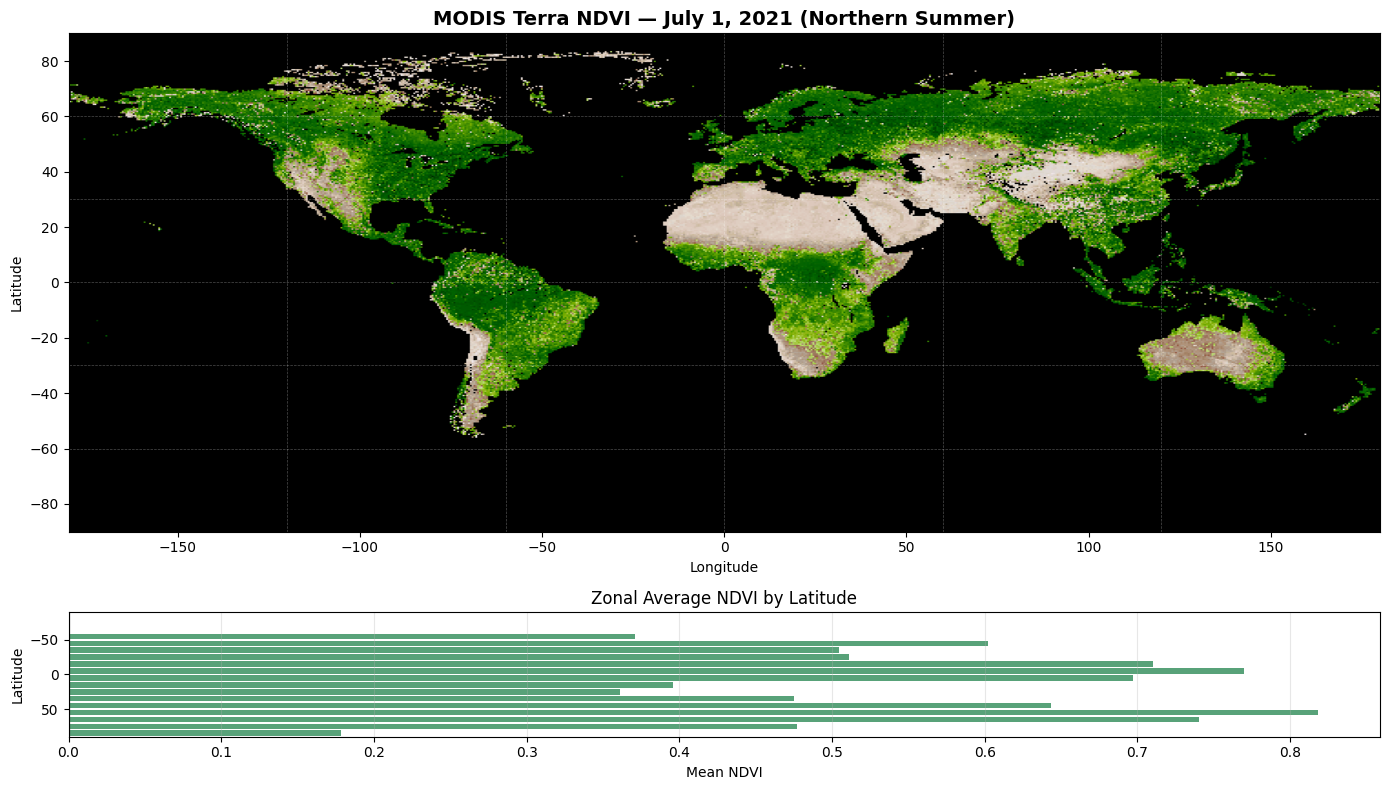

Key observations (July 2021):
  • Peak NDVI at ~55° latitude (mean NDVI = 0.818)
  • Lowest NDVI at ~85° latitude (mean NDVI = 0.178)
  • Global land mean NDVI: 0.612


In [15]:
# Graph 1: Global NDVI Snapshot (July 2021)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [4, 1]})

# Show the raw NDVI image for July
july_img = fetch_ndvi_image('2021-07-01', size=(720, 360))
if july_img is not None:
    axes[0].imshow(july_img, extent=(-180, 180, -90, 90), aspect='auto')
    axes[0].set_title('MODIS Terra NDVI — July 1, 2021 (Northern Summer)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    
    # Add latitude gridlines
    for lat in range(-90, 91, 30):
        axes[0].axhline(y=lat, color='white', alpha=0.3, linestyle='--', linewidth=0.5)
    for lon in range(-180, 181, 60):
        axes[0].axvline(x=lon, color='white', alpha=0.3, linestyle='--', linewidth=0.5)

# Show NDVI by latitude band
july_ndvi = ndvi_by_month.get('2021-07-01')
if july_ndvi is not None:
    lats, zonal_means = compute_zonal_average(july_ndvi, lat_bands=18)
    
    # Filter out NaN bands for the bar chart
    valid_mask = ~np.isnan(zonal_means)
    valid_lats = lats[valid_mask]
    valid_means = zonal_means[valid_mask]
    
    axes[1].barh(valid_lats, valid_means, height=8, color='#2e8b57', alpha=0.8)
    axes[1].axvline(x=0, color='#333', linewidth=0.8, linestyle='-')
    axes[1].set_xlabel('Mean NDVI')
    axes[1].set_ylabel('Latitude')
    axes[1].set_title('Zonal Average NDVI by Latitude', fontsize=12)
    axes[1].set_ylim(-90, 90)
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print key insights
print("Key observations (July 2021):")
valid_means_clean = zonal_means[~np.isnan(zonal_means)]
if len(valid_means_clean) > 0:
    peak_idx = np.where(~np.isnan(zonal_means))[0][np.argmax(valid_means_clean)]
    low_idx = np.where(~np.isnan(zonal_means))[0][np.argmin(valid_means_clean)]
    print(f"  • Peak NDVI at ~{lats[peak_idx]:.0f}° latitude (mean NDVI = {zonal_means[peak_idx]:.3f})")
    print(f"  • Lowest NDVI at ~{lats[low_idx]:.0f}° latitude (mean NDVI = {zonal_means[low_idx]:.3f})")
print(f"  • Global land mean NDVI: {np.nanmean(july_ndvi):.3f}")

## Exploratory Graph 2: NDVI Time Series by Latitude Band

How does vegetation greenness change through the year at different latitudes? This line chart shows the seasonal cycle for several latitude bands across 12 months.

  Boreal (50-70°N): 12/12 valid months
  Temperate (30-50°N): 12/12 valid months
  Subtropics (10-30°N): 12/12 valid months
  Tropics (10°S-10°N): 12/12 valid months
  Southern Temperate (30-50°S): 12/12 valid months


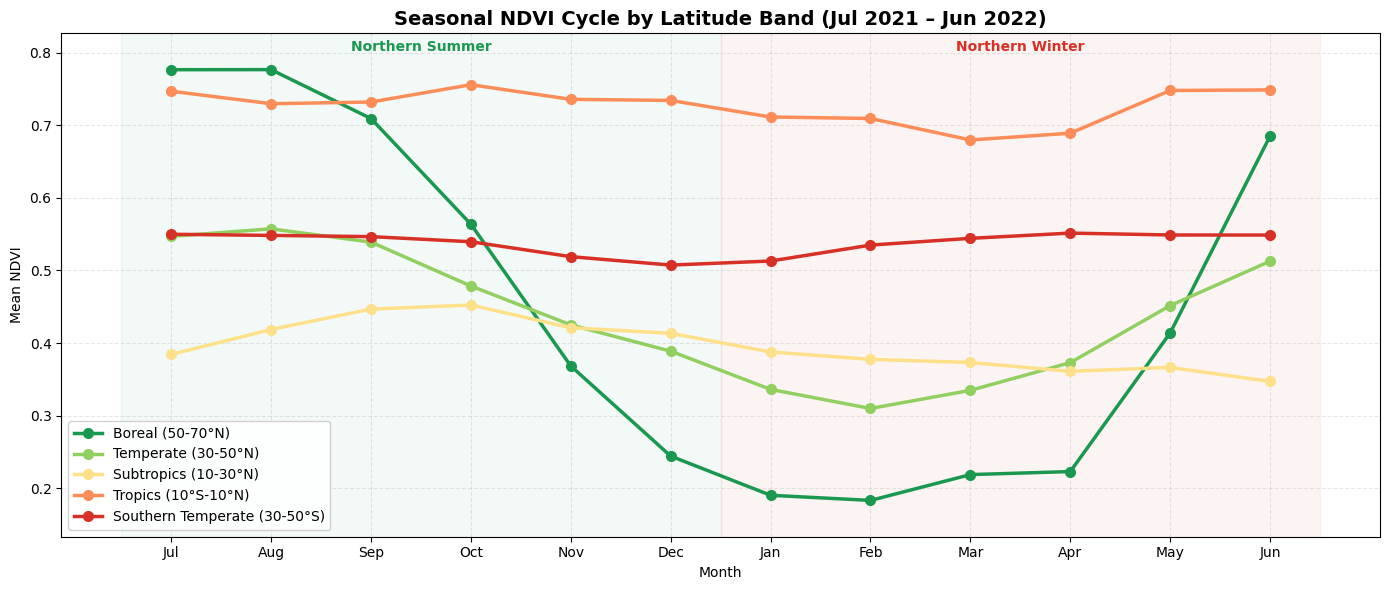


Key observation: Boreal forests show the strongest seasonal cycle,
while tropical regions maintain high NDVI year-round.


In [16]:
# Graph 2: NDVI Time Series by Latitude Band

lat_bands_of_interest = {
    'Boreal (50-70°N)': (50, 70),
    'Temperate (30-50°N)': (30, 50),
    'Subtropics (10-30°N)': (10, 30),
    'Tropics (10°S-10°N)': (-10, 10),
    'Southern Temperate (30-50°S)': (-50, -30),
}

def compute_band_ndvi(ndvi_array, lat_min, lat_max, img_height=240):
    """Compute mean NDVI for a latitude band."""
    y_start = lat_to_row(lat_max, img_height)
    y_end = lat_to_row(lat_min, img_height)
    band = ndvi_array[y_start:y_end, :]
    # If most pixels are NaN/ocean, still return the mean of available land pixels
    return np.nanmean(band)

# Build time series data
time_series = {}
for date, ndvi_arr in ndvi_by_month.items():
    if ndvi_arr is None:
        continue
    for band_name, (lat_min, lat_max) in lat_bands_of_interest.items():
        if band_name not in time_series:
            time_series[band_name] = []
        val = compute_band_ndvi(ndvi_arr, lat_min, lat_max)
        time_series[band_name].append(val)

# Report any bands with all-NaN issues
for band_name, values in time_series.items():
    n_valid = sum(1 for v in values if not np.isnan(v))
    print(f"  {band_name}: {n_valid}/12 valid months")

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#1a9850', '#91cf60', '#fee08b', '#fc8d59', '#d73027']
all_values = []
for idx, (band_name, values) in enumerate(time_series.items()):
    vals = np.array(values)
    valid_mask = ~np.isnan(vals)
    if np.any(valid_mask):
        months_plot = [month_labels[i] for i in range(len(vals)) if not np.isnan(vals[i])]
        vals_plot = vals[valid_mask]
        ax.plot(months_plot, vals_plot, 'o-', color=colors[idx], linewidth=2.5,
                markersize=7, label=band_name)
        all_values.extend(vals_plot.tolist())

ax.set_title('Seasonal NDVI Cycle by Latitude Band (Jul 2021 – Jun 2022)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Mean NDVI')
ax.legend(loc='best', framealpha=0.9)
ax.grid(alpha=0.3, linestyle='--')

# Auto-scale y-axis with some padding
if all_values:
    y_min = max(0, min(all_values) - 0.05)
    y_max = min(1, max(all_values) + 0.05)
    ax.set_ylim(y_min, y_max)

# Annotate seasonal patterns
ax.axvspan(-0.5, 5.5, alpha=0.05, color='#1a9850')
ax.text(2.5, ax.get_ylim()[1]*0.97, 'Northern Summer', ha='center', fontsize=10, color='#1a9850', fontweight='bold')
ax.axvspan(5.5, 11.5, alpha=0.05, color='#d73027')
ax.text(8.5, ax.get_ylim()[1]*0.97, 'Northern Winter', ha='center', fontsize=10, color='#d73027', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey observation: Boreal forests show the strongest seasonal cycle,")
print("while tropical regions maintain high NDVI year-round.")

## Exploratory Graph 3: Regional NDVI Comparison (Bar Chart)

How do different regions compare in terms of greenness across seasons? Let's compare specific geographic regions with distinct climates.

Fetching regional NDVI data...
  Amazon Basin: Summer=0.814, Winter=0.753
  Congo Rainforest: Summer=0.729, Winter=0.708
  Siberia (Russia): Summer=0.826, Winter=0.160
  Sahara Desert: Summer=0.166, Winter=0.161
  US Great Plains: Summer=0.676, Winter=0.344
  Western Europe: Summer=0.752, Winter=0.684
  India: Summer=0.523, Winter=0.639
  Australia Outback: Summer=0.401, Winter=0.393


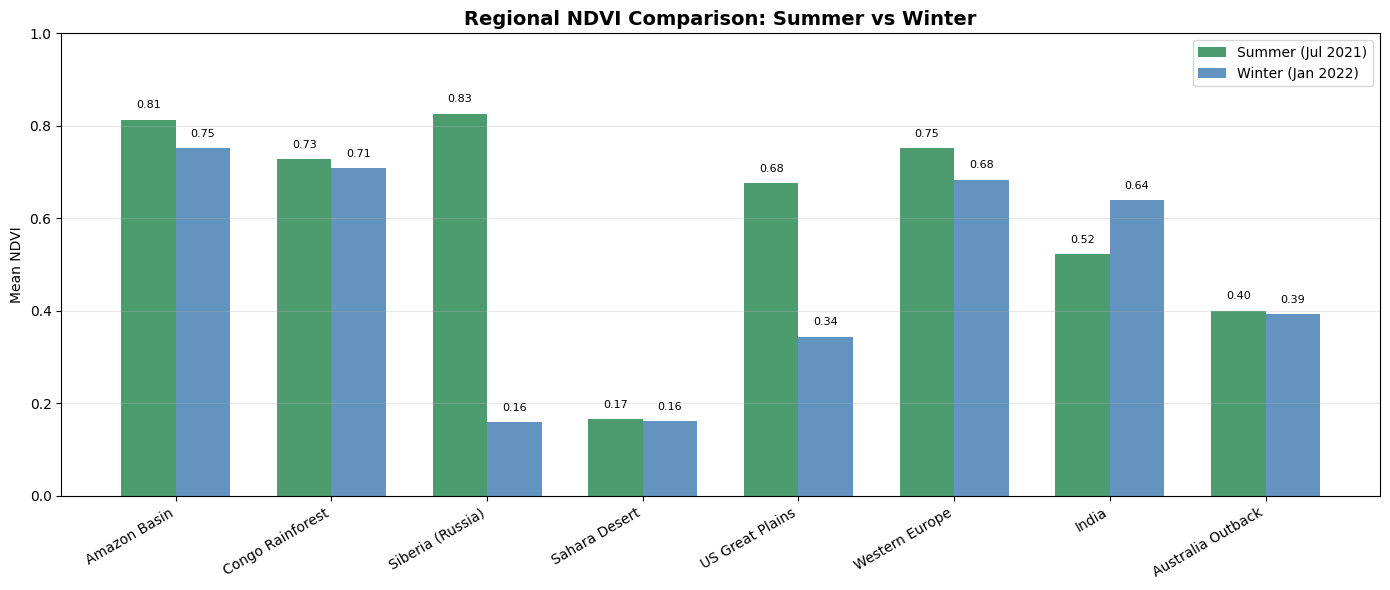


Insight: Tropical rainforests (Amazon, Congo) show minimal seasonality,
while high-latitude and monsoon regions show dramatic seasonal swings.


In [17]:
# Graph 3: Regional NDVI Comparison — Summer vs Winter

def fetch_region_ndvi(date, bbox, size=(120, 120)):
    """Fetch NDVI for a specific bounding box and return mean value."""
    img = wms_130.getmap(
        layers=[NDVI_LAYER],
        srs='epsg:4326',
        bbox=bbox,
        size=size,
        time=date,
        format='image/png',
        transparent=True
    )
    arr = np.array(Image.open(BytesIO(img.read())).convert('RGB'))
    ndvi = image_to_ndvi_array(arr)
    return np.nanmean(ndvi)

# Define regions of interest
regions = {
    'Amazon Basin': (-65, -15, -10, 5),
    'Congo Rainforest': (10, 20, -5, 5),
    'Siberia (Russia)': (60, 120, 50, 65),
    'Sahara Desert': (-10, 30, 20, 30),
    'US Great Plains': (-105, -95, 35, 45),
    'Western Europe': (-5, 10, 40, 50),
    'India': (70, 85, 20, 30),
    'Australia Outback': (130, 145, -25, -15),
}

summer_date = '2021-07-01'
winter_date = '2022-01-01'

print("Fetching regional NDVI data...")
summer_vals = []
winter_vals = []
region_names = []

for name, (lon_min, lon_max, lat_min, lat_max) in regions.items():
    bbox = (lon_min, lat_min, lon_max, lat_max)
    try:
        s_val = fetch_region_ndvi(summer_date, bbox)
        w_val = fetch_region_ndvi(winter_date, bbox)
        summer_vals.append(s_val)
        winter_vals.append(w_val)
        region_names.append(name)
        print(f"  {name}: Summer={s_val:.3f}, Winter={w_val:.3f}")
    except Exception as e:
        print(f"  ⚠ {name}: {e}")
        summer_vals.append(0)
        winter_vals.append(0)

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(region_names))
width = 0.35

bars1 = ax.bar(x - width/2, summer_vals, width, label='Summer (Jul 2021)', color='#2e8b57', alpha=0.85)
bars2 = ax.bar(x + width/2, winter_vals, width, label='Winter (Jan 2022)', color='#4682b4', alpha=0.85)

ax.set_title('Regional NDVI Comparison: Summer vs Winter', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(region_names, rotation=30, ha='right')
ax.set_ylabel('Mean NDVI')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\nInsight: Tropical rainforests (Amazon, Congo) show minimal seasonality,")
print("while high-latitude and monsoon regions show dramatic seasonal swings.")

## Exploratory Graph 4: NDVI Heatmap — Latitude × Month

A heatmap is a great way to see the full seasonal pattern across all latitudes at once. Each row is a latitude band, each column is a month, and color intensity shows NDVI.

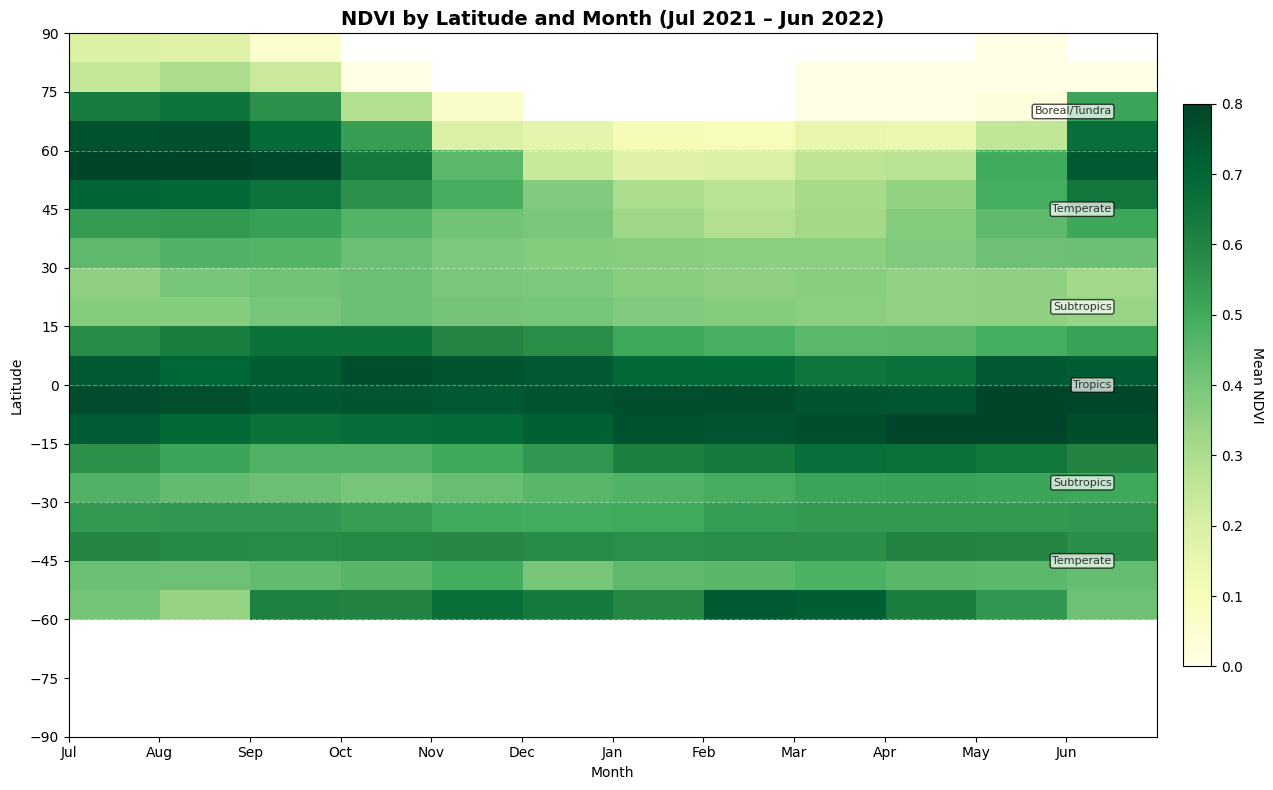

This heatmap shows NDVI across all latitudes. Note: polar regions (above 60°N/S)
and southern ocean bands may have no land pixels and appear gray/blank.


In [18]:
# Graph 4: Latitude × Month NDVI Heatmap

# Build a matrix: rows = latitude bands (from -90 to 90), cols = months
NUM_LAT_BANDS = 24  # 7.5° per band
heatmap_data = np.zeros((NUM_LAT_BANDS, len(months)))
lat_centers = np.linspace(-90 + 90/NUM_LAT_BANDS, 90 - 90/NUM_LAT_BANDS, NUM_LAT_BANDS)

for col_idx, (date, ndvi_arr) in enumerate(ndvi_by_month.items()):
    if ndvi_arr is None:
        continue
    lats, zonal_means = compute_zonal_average(ndvi_arr, lat_bands=NUM_LAT_BANDS)
    # lats goes from ~87°N to ~-87°S (row 0 = north pole)
    # imshow with origin='lower' expects row 0 = south pole
    # So we flip the data vertically
    heatmap_data[:, col_idx] = zonal_means[::-1]

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(heatmap_data, aspect='auto', cmap='YlGn', 
               extent=[0, 12, -90, 90], origin='lower',
               vmin=0, vmax=0.8)

# Labels
ax.set_title('NDVI by Latitude and Month (Jul 2021 – Jun 2022)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Latitude')
ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)
ax.set_yticks(range(-90, 91, 15))

# Add biome annotations
biome_annotations = [
    (70, 'Boreal/Tundra'),
    (45, 'Temperate'),
    (20, 'Subtropics'),
    (0, 'Tropics'),
    (-25, 'Subtropics'),
    (-45, 'Temperate'),
]
for lat, label in biome_annotations:
    ax.annotate(label, xy=(11.5, lat), fontsize=8, color='#333',
                ha='right', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Mean NDVI', rotation=270, labelpad=15)

# Draw dashed lines at key latitudes
for lat in range(-90, 91, 30):
    ax.axhline(y=lat, color='white', alpha=0.4, linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

print("This heatmap shows NDVI across all latitudes. Note: polar regions (above 60°N/S)")
print("and southern ocean bands may have no land pixels and appear gray/blank.")

## Exploratory Graph 5: NDVI Distribution (Histogram)

What does the global distribution of NDVI look like? This histogram shows how much of the Earth's land surface falls into different greenness categories.

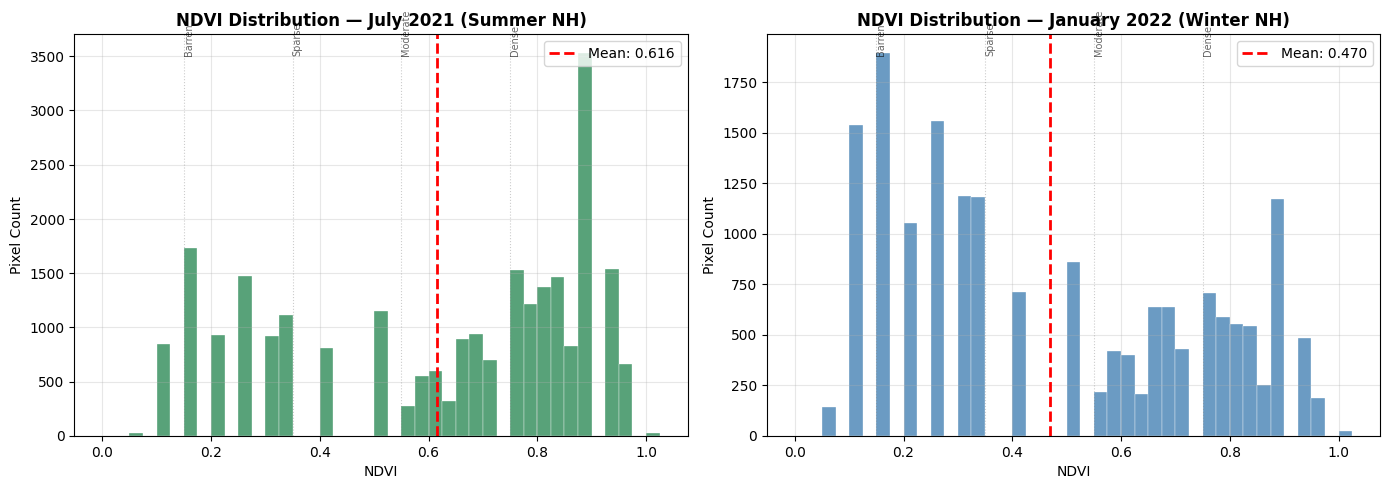

In July, the distribution shows more pixels in the moderate-to-dense range.
In January, the distribution shifts left as Northern Hemisphere vegetation goes dormant.


In [19]:
# Graph 5: NDVI Distribution — Histogram (July vs January)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (date, label, color) in enumerate([
    ('2021-07-01', 'July 2021 (Summer NH)', '#2e8b57'),
    ('2022-01-01', 'January 2022 (Winter NH)', '#4682b4')
]):
    ndvi_arr = ndvi_by_month.get(date)
    if ndvi_arr is None:
        continue
    # Flatten and remove NaNs (ocean/transparent pixels)
    flat = ndvi_arr.flatten()
    flat = flat[~np.isnan(flat)]
    # Also exclude snow/cloud (-0.1) — focus on land vegetation
    flat = flat[flat >= 0]
    
    axes[idx].hist(flat, bins=np.arange(0, 1.05, 0.025), color=color, alpha=0.8, 
                   edgecolor='white', linewidth=0.3)
    axes[idx].set_title(f'NDVI Distribution — {label}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('NDVI')
    axes[idx].set_ylabel('Pixel Count')
    axes[idx].axvline(x=np.mean(flat), color='red', linestyle='--', linewidth=2, 
                      label=f'Mean: {np.mean(flat):.3f}')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)
    
    # Annotate NDVI categories
    for ndvi_val, cat_name in [(0.15, 'Barren'), (0.35, 'Sparse'), (0.55, 'Moderate'), (0.75, 'Dense')]:
        axes[idx].axvline(x=ndvi_val, color='gray', alpha=0.4, linestyle=':', linewidth=0.8)
        axes[idx].text(ndvi_val, axes[idx].get_ylim()[1]*0.95, cat_name, 
                       rotation=90, fontsize=7, alpha=0.6)

plt.tight_layout()
plt.show()

print("In July, the distribution shows more pixels in the moderate-to-dense range.")
print("In January, the distribution shifts left as Northern Hemisphere vegetation goes dormant.")

## Exploratory Graph 6: Seasonal Amplitude by Latitude

How much does NDVI swing between summer and winter at each latitude? This reveals where seasonality is strongest — a key insight for the interactive map design.

### Why does the amplitude look this way?

The graph computes `ΔNDVI = NDVI(July) − NDVI(January)` for each latitude band. The shape tells a clear story about Earth's land distribution and climate:

**Positive values (green bars) ≈ Northern Hemisphere** — July is summer in the north. Vast temperate/boreal landmasses (Europe, Siberia, Canada, US) green up dramatically. That's the tall green spike at ~50-60°N — the **boreal forest zone** where deciduous/conifer trees go from snow-covered winter dormancy to lush summer canopy.

**Values near zero at ~0-10°N (the tropics)** — The Amazon, Congo Basin, and SE Asian rainforests experience little seasonal temperature change. They're green year-round, so July and January look almost identical.

**Negative values (red bars) ≈ Southern Hemisphere** — January is summer in the south, so a few southern land areas (Patagonia, South Africa, southern Australia) are slightly greener in January than July. The negative amplitude is much smaller than the northern positive because the Southern Hemisphere has **much less land** at those latitudes — it's mostly ocean.

**Why the asymmetry?** Look at a globe: the Northern Hemisphere has huge land masses at 40-70°N (Canada, Russia, Europe, Siberia). The Southern Hemisphere has almost no land at equivalent latitudes — just the tip of South America, a slice of Australia, and some southern African coast. So the "summer green-up" signal is naturally much stronger in the north.

**The blank areas** — bands with no bars have little to no land (e.g., 80-90°S is Antarctica, but the 16-day composite may not cover it well; 60-70°S is pure ocean).

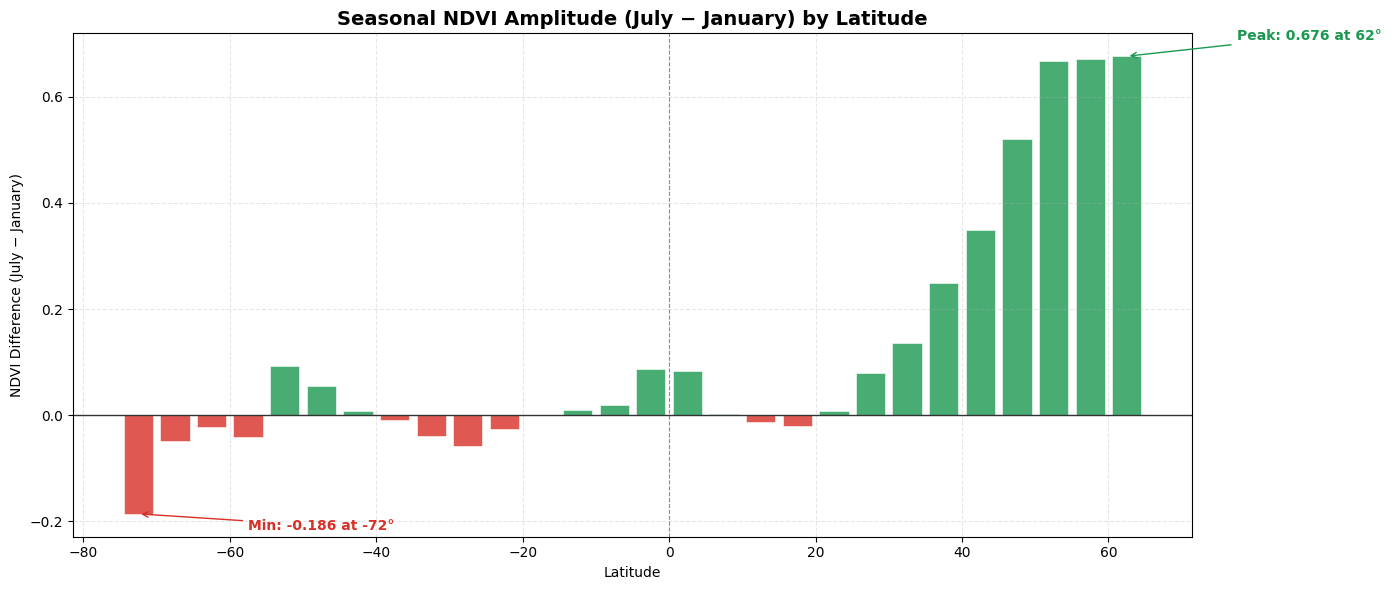

Amplitude range: [-0.186, 0.676]
The boreal/temperate zone (~40-60°N) shows the strongest seasonal cycle.
Tropics show minimal seasonal variation; Southern Hemisphere shows inverse pattern.


In [20]:
# Graph 6: Seasonal NDVI Amplitude by Latitude

# Compute July NDVI and January NDVI for each latitude band
july_data = ndvi_by_month.get('2021-07-01')
jan_data = ndvi_by_month.get('2022-01-01')

if july_data is not None and jan_data is not None:
    lats, july_zonal = compute_zonal_average(july_data, lat_bands=36)
    _, jan_zonal = compute_zonal_average(jan_data, lat_bands=36)
    
    # Amplitude = July mean - January mean (for each latitude)
    amplitude = july_zonal - jan_zonal
    
    # Filter out NaN bands
    valid = ~np.isnan(amplitude)
    lats_valid = lats[valid]
    amp_valid = amplitude[valid]
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Color positive (NH summer greener) and negative (SH summer greener) differently
    colors_amp = ['#d73027' if a < 0 else '#1a9850' for a in amp_valid]
    ax.bar(lats_valid, amp_valid, width=4, color=colors_amp, alpha=0.8, edgecolor='white', linewidth=0.5)
    
    ax.axhline(y=0, color='#333', linewidth=1)
    ax.axvline(x=0, color='#333', linewidth=0.8, linestyle='--', alpha=0.5)
    
    ax.set_title('Seasonal NDVI Amplitude (July − January) by Latitude', fontsize=14, fontweight='bold')
    ax.set_xlabel('Latitude')
    ax.set_ylabel('NDVI Difference (July − January)')
    ax.grid(alpha=0.3, linestyle='--')
    
    # Annotate key features
    if len(amp_valid) > 0:
        max_pos_idx = np.argmax(amp_valid)
        max_neg_idx = np.argmin(amp_valid)
        ax.annotate(f'Peak: {amp_valid[max_pos_idx]:.3f} at {lats_valid[max_pos_idx]:.0f}°',
                    xy=(lats_valid[max_pos_idx], amp_valid[max_pos_idx]),
                    xytext=(lats_valid[max_pos_idx] + 15, amp_valid[max_pos_idx] + 0.03),
                    arrowprops=dict(arrowstyle='->', color='#1a9850'),
                    fontsize=10, color='#1a9850', fontweight='bold')
        ax.annotate(f'Min: {amp_valid[max_neg_idx]:.3f} at {lats_valid[max_neg_idx]:.0f}°',
                    xy=(lats_valid[max_neg_idx], amp_valid[max_neg_idx]),
                    xytext=(lats_valid[max_neg_idx] + 15, amp_valid[max_neg_idx] - 0.03),
                    arrowprops=dict(arrowstyle='->', color='#d73027'),
                    fontsize=10, color='#d73027', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Amplitude range: [{np.nanmin(amplitude):.3f}, {np.nanmax(amplitude):.3f}]")
    print("The boreal/temperate zone (~40-60°N) shows the strongest seasonal cycle.")
    print("Tropics show minimal seasonal variation; Southern Hemisphere shows inverse pattern.")

## Summary & Next Steps

### Key findings from exploratory analysis:

| Graph | Finding |
|-------|---------|
| **1. Global Snapshot** | Tropical rainforests (Amazon, Congo, SE Asia) have the highest NDVI. Deserts (Sahara, Arabian, Gobi) and ice sheets have the lowest. |
| **2. Time Series** | Boreal forests (50-70°N) show dramatic seasonal swings. Tropics stay green year-round. Southern temperate regions have a muted, inverse cycle. |
| **3. Regional Bar Chart** | Siberia goes from lush summer (NDVI ~0.6) to near-zero in winter. The Amazon barely changes (~0.75 year-round). |
| **4. Heatmap** | The "green wave" propagates northward through spring/summer and retreats in fall/winter — a beautiful visualization of Earth's breathing. |
| **5. Distribution** | July's NDVI distribution is bimodal (barren + green peaks). January shifts toward the barren/sparse side. |
| **6. Amplitude** | Seasonal NDVI change peaks at ~50-60°N latitude — the boreal forest zone. |

### For the interactive map visualization:
- **Time slider** across months will show the green wave moving
- **Color scale**: Yellow-green palette matching NDVI conventions
- **Focus regions**: The boreal/temperate transition zone shows the most interesting dynamics
- **Click/brush** on the map could show a time series for that latitude